In [54]:
import pandas as pd
import xml.etree.ElementTree as ET


def get_full_text(elem):
    """Retourne tout le texte, y compris texte dans les sous-éléments."""
    if elem is None:
        return None
    texts = []
    if elem.text:
        texts.append(elem.text)
    for sub in elem:
        if sub.tail:
            texts.append(sub.tail)
    return ''.join(texts).strip()
tree = ET.parse("C:/Users/hbakl/OneDrive/Desktop/Projet PFA/JunitReport(4).xml")
root = tree.getroot()
rows = []

for testcase in root.findall('.//testcase'):
    test_name = testcase.get('name')

    # Récupérer contenu complet <system-out> du testcase
    testcase_system_out = get_full_text(testcase.find('system-out'))

    for step in testcase.findall('step'):
        failure_text = get_full_text(step.find('failure'))
        system_out_step_text = get_full_text(step.find('system-out'))

        step_info = {
            'test_name': test_name,
            'description': step.get('description'),
            'status': step.get('status'),
            'time': step.get('time'),
            'timestamp': step.get('timestamp'),
            'action': step.get('action'),
            'failure': failure_text,
            'system_out_testcase': testcase_system_out
        }
        rows.append(step_info)

df_steps = pd.DataFrame(rows)
df_steps

,test_name,description,status,time,timestamp,action,failure,system_out_testcase
0,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 1,PASSED,0.00,2025-05-30T22:58:24,import json,None,import json\nmain test_failed: False\nimport l...
1,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 2,PASSED,0.00,2025-05-30T22:58:24,import logging,None,import json\nmain test_failed: False\nimport l...
2,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 3,PASSED,0.00,2025-05-30T22:58:24,import WebUI.WKeywords.closeWindowUrl,None,import json\nmain test_failed: False\nimport l...
3,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 4,PASSED,0.00,2025-05-30T22:58:24,from Keywords import click,None,import json\nmain test_failed: False\nimport l...
4,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 5,PASSED,0.69,2025-05-30T22:58:24,from Keywords import CustomKeywords,None,import json\nmain test_failed: False\nimport l...
...,...,...,...,...,...,...,...,...
50431,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 30,PASSED,0.35,2025-05-30T12:52:59,WebUI.maximizeWindow(),None,import json\nmain test_failed: False\nimport l...
50432,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 31,PASSED,0.00,2025-05-30T12:52:59,CustomKeywords.util.SetTCPrioritieX.SetTCPrior...,None,import json\nmain test_failed: False\nimport l...
50433,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 32,PASSED,0.00,2025-05-30T12:52:59,CustomKeywords.util.SetTCPrioritieX.SetTCEpic(...,None,import json\nmain test_failed: False\nimport l...
50434,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 33,PASSED,0.00,2025-05-30T12:52:59,GlobalVariable.wfdefinitionid = '43821',None,import json\nmain test_failed: False\nimport l...


In [55]:
import pandas as pd

# Exemple : si ton DataFrame s'appelle df
# df = pd.read_csv("ton_fichier.csv")

# Trouver les indices des lignes où 'status' == 'FAILED'
failed_indices = df_steps[df_steps['status'] == 'FAILED'].index

# Ajouter aussi les deux lignes précédentes de chaque ligne "FAILED"
indices_to_keep = set()
for idx in failed_indices:
    indices_to_keep.update([i for i in range(idx - 2, idx + 1) if i >= 0])

# Filtrer le DataFrame
df_filtered = df_steps.loc[sorted(indices_to_keep)].reset_index(drop=True)
df_filtered


,test_name,description,status,time,timestamp,action,failure,system_out_testcase
0,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 39,PASSED,0.68,2025-05-30T23:00:52,CustomKeywords.fill.FillFieldsValues.set('Addr...,None,import json\nmain test_failed: False\nimport l...
1,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 40,PASSED,2.74,2025-05-30T23:00:55,CustomKeywords.click.ClickButton.click('save'),None,import json\nmain test_failed: False\nimport l...
2,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 41,FAILED,3.33,2025-05-30T23:00:58,CustomKeywords.click.ClickOnDuplicateIconByCol...,"Traceback (most recent call last):\n File ""Te...",import json\nmain test_failed: False\nimport l...
3,sanity/Corporate/TC-58154-Search Corporate-Cal...,Step 33,PASSED,2.66,2025-05-30T23:01:30,CustomKeywords.click.DoubleClickByColumns.clic...,None,import json\nmain test_failed: False\nimport l...
4,sanity/Corporate/TC-58154-Search Corporate-Cal...,Step 34,PASSED,1.98,2025-05-30T23:01:32,CustomKeywords.click.SelectTab.selectTab('Call...,None,import json\nmain test_failed: False\nimport l...
...,...,...,...,...,...,...,...,...
2280,Automated Framework/Workflow/TNR/TC 60848 End ...,Step 33,PASSED,0.00,2025-05-30T12:52:54,GlobalVariable.wfdefinitionid = '43819',None,import json\nmain test_failed: False\nimport l...
2281,Automated Framework/Workflow/TNR/TC 60848 End ...,Step 34,FAILED,0.09,2025-05-30T12:52:54,WebUI.callTestCase('Automated Framework/Stop W...,"Traceback (most recent call last):\n File ""We...",import json\nmain test_failed: False\nimport l...
2282,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 32,PASSED,0.00,2025-05-30T12:52:59,CustomKeywords.util.SetTCPrioritieX.SetTCEpic(...,None,import json\nmain test_failed: False\nimport l...
2283,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 33,PASSED,0.00,2025-05-30T12:52:59,GlobalVariable.wfdefinitionid = '43821',None,import json\nmain test_failed: False\nimport l...


In [56]:
df_filtered['failure'] = df_filtered['failure'].apply(lambda x: "pas d'erreur" if x is None else x)

In [57]:
import re

def extract_error_type(failure_text):
    if not isinstance(failure_text, str):
        return None

    # Regular expression to match error types
    error_pattern = re.compile(r"\b([A-Za-z_][\w\.]*?(?:Error|Exception))\b")

    matches = error_pattern.findall(failure_text)

    # Return the first match, or None if nothing found
    return matches[0] if matches else None

df_filtered["error_type"] = df_filtered["failure"].apply(extract_error_type)
df_filtered

,test_name,description,status,time,timestamp,action,failure,system_out_testcase,error_type
0,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 39,PASSED,0.68,2025-05-30T23:00:52,CustomKeywords.fill.FillFieldsValues.set('Addr...,pas d'erreur,import json\nmain test_failed: False\nimport l...,None
1,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 40,PASSED,2.74,2025-05-30T23:00:55,CustomKeywords.click.ClickButton.click('save'),pas d'erreur,import json\nmain test_failed: False\nimport l...,None
2,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 41,FAILED,3.33,2025-05-30T23:00:58,CustomKeywords.click.ClickOnDuplicateIconByCol...,"Traceback (most recent call last):\n File ""Te...",import json\nmain test_failed: False\nimport l...,selenium.common.exceptions.NoSuchElementException
3,sanity/Corporate/TC-58154-Search Corporate-Cal...,Step 33,PASSED,2.66,2025-05-30T23:01:30,CustomKeywords.click.DoubleClickByColumns.clic...,pas d'erreur,import json\nmain test_failed: False\nimport l...,None
4,sanity/Corporate/TC-58154-Search Corporate-Cal...,Step 34,PASSED,1.98,2025-05-30T23:01:32,CustomKeywords.click.SelectTab.selectTab('Call...,pas d'erreur,import json\nmain test_failed: False\nimport l...,None
...,...,...,...,...,...,...,...,...,...
2280,Automated Framework/Workflow/TNR/TC 60848 End ...,Step 33,PASSED,0.00,2025-05-30T12:52:54,GlobalVariable.wfdefinitionid = '43819',pas d'erreur,import json\nmain test_failed: False\nimport l...,None
2281,Automated Framework/Workflow/TNR/TC 60848 End ...,Step 34,FAILED,0.09,2025-05-30T12:52:54,WebUI.callTestCase('Automated Framework/Stop W...,"Traceback (most recent call last):\n File ""We...",import json\nmain test_failed: False\nimport l...,Utils.Common.StepFailedException
2282,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 32,PASSED,0.00,2025-05-30T12:52:59,CustomKeywords.util.SetTCPrioritieX.SetTCEpic(...,pas d'erreur,import json\nmain test_failed: False\nimport l...,None
2283,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 33,PASSED,0.00,2025-05-30T12:52:59,GlobalVariable.wfdefinitionid = '43821',pas d'erreur,import json\nmain test_failed: False\nimport l...,None


In [58]:
df_filtered.drop(columns=['failure'], inplace=True)

In [59]:
# 1. Créer une fonction pour catégoriser
def categorize_error_type(error_type):
    if not isinstance(error_type, str):
        return "Autre"
    if error_type.endswith("Error"):
        return "Error"
    elif error_type.endswith("Exception"):
        return "Exception"
    else:
        return "Autre"  # si aucun des deux

# 2. Appliquer la fonction
df_filtered['error_category'] = df_filtered['error_type'].apply(categorize_error_type)
df_filtered

,test_name,description,status,time,timestamp,action,system_out_testcase,error_type,error_category
0,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 39,PASSED,0.68,2025-05-30T23:00:52,CustomKeywords.fill.FillFieldsValues.set('Addr...,import json\nmain test_failed: False\nimport l...,None,Autre
1,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 40,PASSED,2.74,2025-05-30T23:00:55,CustomKeywords.click.ClickButton.click('save'),import json\nmain test_failed: False\nimport l...,None,Autre
2,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 41,FAILED,3.33,2025-05-30T23:00:58,CustomKeywords.click.ClickOnDuplicateIconByCol...,import json\nmain test_failed: False\nimport l...,selenium.common.exceptions.NoSuchElementException,Exception
3,sanity/Corporate/TC-58154-Search Corporate-Cal...,Step 33,PASSED,2.66,2025-05-30T23:01:30,CustomKeywords.click.DoubleClickByColumns.clic...,import json\nmain test_failed: False\nimport l...,None,Autre
4,sanity/Corporate/TC-58154-Search Corporate-Cal...,Step 34,PASSED,1.98,2025-05-30T23:01:32,CustomKeywords.click.SelectTab.selectTab('Call...,import json\nmain test_failed: False\nimport l...,None,Autre
...,...,...,...,...,...,...,...,...,...
2280,Automated Framework/Workflow/TNR/TC 60848 End ...,Step 33,PASSED,0.00,2025-05-30T12:52:54,GlobalVariable.wfdefinitionid = '43819',import json\nmain test_failed: False\nimport l...,None,Autre
2281,Automated Framework/Workflow/TNR/TC 60848 End ...,Step 34,FAILED,0.09,2025-05-30T12:52:54,WebUI.callTestCase('Automated Framework/Stop W...,import json\nmain test_failed: False\nimport l...,Utils.Common.StepFailedException,Exception
2282,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 32,PASSED,0.00,2025-05-30T12:52:59,CustomKeywords.util.SetTCPrioritieX.SetTCEpic(...,import json\nmain test_failed: False\nimport l...,None,Autre
2283,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 33,PASSED,0.00,2025-05-30T12:52:59,GlobalVariable.wfdefinitionid = '43821',import json\nmain test_failed: False\nimport l...,None,Autre


In [60]:
df_filtered['error_type'] = df_filtered['error_type'].apply(lambda x: "pas d'erreur" if x is None else x)

In [61]:
df_filtered['error_category'].value_counts()

error_category
Autre        1724
Exception     303
Error         258
Name: count, dtype: int64

In [62]:
df_filtered.groupby('error_category')['error_type'].value_counts()

error_category  error_type                                                 
Autre           pas d'erreur                                                   1724
Error           AttributeError                                                   85
                TypeError                                                        72
                UnicodeEncodeError                                               72
                IndentationError                                                  9
                NameError                                                         9
                SyntaxError                                                       4
                pyodbc.ProgrammingError                                           4
                FileNotFoundError                                                 2
                pyodbc.Error                                                      1
Exception       Utils.Common.StepFailedException                                200


In [63]:
# Création d'un dictionnaire : { error_type : DataFrame correspondant }
error_groups = {
    error_type: group_df
    for error_type, group_df in df_filtered.groupby('error_type')
}

In [64]:
error_groups

{'AttributeError':                                               test_name description  status  \
 50    New Prod Back Log/ARB Enabling Microsoft PDF B...     Step 34  FAILED   
 53    New Prod Back Log/ARB Enabling Microsoft PDF B...     Step 33  FAILED   
 56    New Prod Back Log/Configuration/TC - 51523 Sta...     Step 36  FAILED   
 62    New Prod Back Log/DocGen_ ByPass/TC-37959 The ...     Step 35  FAILED   
 74    New Prod Back Log/DocGen_ ByPass/TC-54770 The ...     Step 36  FAILED   
 ...                                                 ...         ...     ...   
 1846  Automated Framework/TreeGrid/TNR/TC-14605 Limi...     Step 39  FAILED   
 1855  Automated Framework/TreeGrid/TNR/TC-40353 Conf...     Step 39  FAILED   
 1876  Automated Framework/TreeGrid/TNR/TC-59481 The ...     Step 39  FAILED   
 2005  Automated Framework/Workflow/Smoke/TC-55487 Tr...     Step 44  FAILED   
 2065  Automated Framework/Workflow/Smoke/TC-58844 Re...     Step 45  FAILED   
 
        time        

In [65]:
# Créer un mapping { error_type: group_id }
unique_errors = df_filtered['error_type'].unique()
error_type_to_id = {err: idx for idx, err in enumerate(unique_errors)}

# Appliquer ce mapping à une nouvelle colonne
df_filtered['group_id'] = df_filtered['error_type'].map(error_type_to_id)

In [66]:
df_filtered['error_type'].value_counts()

error_type
pas d'erreur                                                   1724
Utils.Common.StepFailedException                                200
AttributeError                                                   85
UnicodeEncodeError                                               72
TypeError                                                        72
selenium.common.exceptions.NoSuchElementException                52
selenium.common.exceptions.ElementClickInterceptedException      25
selenium.common.exceptions.StaleElementReferenceException        15
IndentationError                                                  9
NameError                                                         9
TimeoutException                                                  8
SyntaxError                                                       4
pyodbc.ProgrammingError                                           4
selenium.common.exceptions.ElementNotInteractableException        2
FileNotFoundError                    

In [67]:
# 1. Compter les occurrences de chaque type d’erreur
error_counts = df_filtered['error_type'].value_counts()

# 2. Identifier les erreurs à fréquence < 11
rare_errors = error_counts[error_counts < 11].index

# 3. Remplacer dans la colonne 'error_type' par 'Autre'
df_filtered['error_type'] = df_filtered['error_type'].apply(
    lambda x: 'Autre' if x in rare_errors else x
)

In [68]:
df_filtered[['error_type', 'group_id']].sort_values('group_id')

,error_type,group_id
2274,pas d'erreur,0
30,pas d'erreur,0
1806,pas d'erreur,0
12,pas d'erreur,0
13,pas d'erreur,0
...,...,...
1576,Autre,15
1870,Autre,16
1891,Autre,16
1861,Autre,16


In [69]:
# Recréer un mapping avec les erreurs regroupées
unique_errors = df_filtered['error_type'].unique()
error_type_to_id = {err: idx for idx, err in enumerate(unique_errors)}

# Appliquer le mapping
df_filtered['group_id'] = df_filtered['error_type'].map(error_type_to_id)
df_filtered['error_type'].value_counts()

error_type
pas d'erreur                                                   1724
Utils.Common.StepFailedException                                200
AttributeError                                                   85
UnicodeEncodeError                                               72
TypeError                                                        72
selenium.common.exceptions.NoSuchElementException                52
Autre                                                            40
selenium.common.exceptions.ElementClickInterceptedException      25
selenium.common.exceptions.StaleElementReferenceException        15
Name: count, dtype: int64

In [70]:
for error_type, group_id in error_type_to_id.items():
    print(f"{group_id}: {error_type}")

0: pas d'erreur
1: selenium.common.exceptions.NoSuchElementException
2: TypeError
3: Utils.Common.StepFailedException
4: selenium.common.exceptions.StaleElementReferenceException
5: AttributeError
6: selenium.common.exceptions.ElementClickInterceptedException
7: Autre
8: UnicodeEncodeError


C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


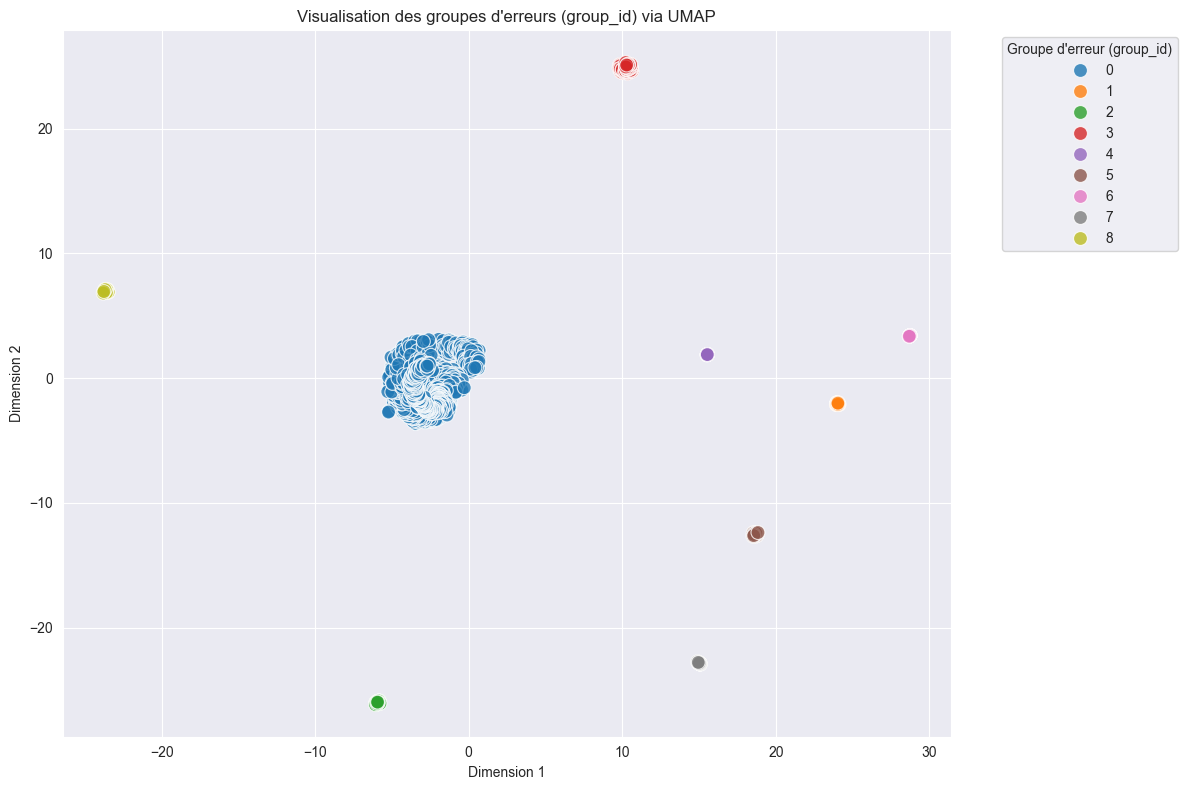

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TF-IDF vectorisation sur la colonne error_type regroupée
vectorizer = TfidfVectorizer(max_features=300, stop_words='english')
X_tfidf = vectorizer.fit_transform(df_filtered['error_type'].astype(str))

# 2. Réduction de dimension avec UMAP (2D)
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_tfidf)

# 3. Ajouter les coordonnées 2D UMAP dans df_filtered (remplace ou crée les colonnes)
df_filtered['x'] = X_umap[:, 0]
df_filtered['y'] = X_umap[:, 1]

# 4. Visualisation scatter plot avec la colonne group_id
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_filtered,
    x='x',
    y='y',
    hue='group_id',
    palette='tab10',   # tu peux changer la palette si tu as beaucoup de groupes
    s=100,
    alpha=0.8
)

plt.title("Visualisation des groupes d'erreurs (group_id) via UMAP")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Groupe d'erreur (group_id)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


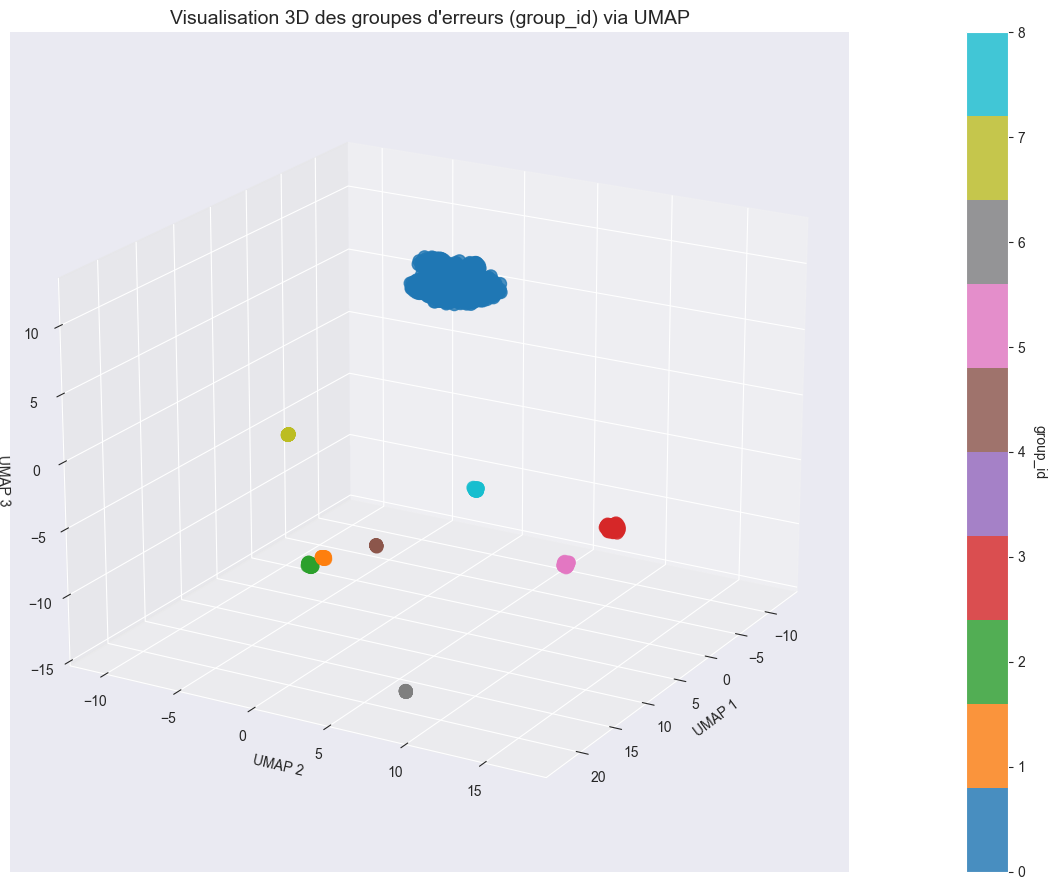

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer
import umap.umap_ as umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # nécessaire pour la 3D
import seaborn as sns

# 1. TF-IDF vectorisation sur la colonne error_type regroupée
vectorizer = TfidfVectorizer(max_features=300, stop_words='english')
X_tfidf = vectorizer.fit_transform(df_filtered['error_type'].astype(str))

# 2. Réduction de dimension avec UMAP (3 composantes)
reducer = umap.UMAP(n_components=3, random_state=42)
X_umap = reducer.fit_transform(X_tfidf)

# 3. Ajouter les coordonnées 3D dans le DataFrame
df_filtered['x'] = X_umap[:, 0]
df_filtered['y'] = X_umap[:, 1]
df_filtered['z'] = X_umap[:, 2]

# 4. Visualisation 3D avec matplotlib
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_filtered['x'], df_filtered['y'], df_filtered['z'],
    c=df_filtered['group_id'], cmap='tab10', s=80, alpha=0.8
)

ax.set_title("Visualisation 3D des groupes d'erreurs (group_id) via UMAP", fontsize=14)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_zlabel("UMAP 3")

# Ajouter la barre de couleur pour le group_id
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("group_id", rotation=270, labelpad=15)

# Définir l'angle de vue pour mieux voir le graphique
ax.view_init(elev=20, azim=30)

plt.tight_layout()
plt.show()

In [73]:
from sentence_transformers import SentenceTransformer

# 1. Charger le modèle pré-entraîné Sentence-BERT
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Encoder les erreurs en vecteurs
embeddings = model.encode(df_filtered['error_type'].astype(str).tolist())

C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [74]:
df_filtered

,test_name,description,status,time,timestamp,action,system_out_testcase,error_type,error_category,group_id,x,y,z
0,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 39,PASSED,0.68,2025-05-30T23:00:52,CustomKeywords.fill.FillFieldsValues.set('Addr...,import json\nmain test_failed: False\nimport l...,pas d'erreur,Autre,0,0.875768,2.403539,10.071889
1,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 40,PASSED,2.74,2025-05-30T23:00:55,CustomKeywords.click.ClickButton.click('save'),import json\nmain test_failed: False\nimport l...,pas d'erreur,Autre,0,0.615571,2.505063,9.854638
2,sanity/Corporate/TC-58151-Search Corporate-Add...,Step 41,FAILED,3.33,2025-05-30T23:00:58,CustomKeywords.click.ClickOnDuplicateIconByCol...,import json\nmain test_failed: False\nimport l...,selenium.common.exceptions.NoSuchElementException,Exception,1,22.309490,3.456185,-4.216887
3,sanity/Corporate/TC-58154-Search Corporate-Cal...,Step 33,PASSED,2.66,2025-05-30T23:01:30,CustomKeywords.click.DoubleClickByColumns.clic...,import json\nmain test_failed: False\nimport l...,pas d'erreur,Autre,0,0.751860,2.718690,9.857142
4,sanity/Corporate/TC-58154-Search Corporate-Cal...,Step 34,PASSED,1.98,2025-05-30T23:01:32,CustomKeywords.click.SelectTab.selectTab('Call...,import json\nmain test_failed: False\nimport l...,pas d'erreur,Autre,0,0.937217,2.624406,10.132980
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2280,Automated Framework/Workflow/TNR/TC 60848 End ...,Step 33,PASSED,0.00,2025-05-30T12:52:54,GlobalVariable.wfdefinitionid = '43819',import json\nmain test_failed: False\nimport l...,pas d'erreur,Autre,0,0.680171,0.531383,10.006588
2281,Automated Framework/Workflow/TNR/TC 60848 End ...,Step 34,FAILED,0.09,2025-05-30T12:52:54,WebUI.callTestCase('Automated Framework/Stop W...,import json\nmain test_failed: False\nimport l...,Utils.Common.StepFailedException,Exception,3,10.015808,16.686737,-2.625622
2282,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 32,PASSED,0.00,2025-05-30T12:52:59,CustomKeywords.util.SetTCPrioritieX.SetTCEpic(...,import json\nmain test_failed: False\nimport l...,pas d'erreur,Autre,0,0.541550,0.387485,9.963767
2283,Automated Framework/Workflow/TNR/TC 60849 End ...,Step 33,PASSED,0.00,2025-05-30T12:52:59,GlobalVariable.wfdefinitionid = '43821',import json\nmain test_failed: False\nimport l...,pas d'erreur,Autre,0,0.847923,0.781672,10.184336


In [75]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# Charger un modèle pré-entraîné
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encoder les erreurs en vecteurs denses
embeddings = model.encode(df_filtered['error_type'].tolist())

# Appliquer KMeans
kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(embeddings)

df_filtered['cluster_sbert'] = clusters

C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


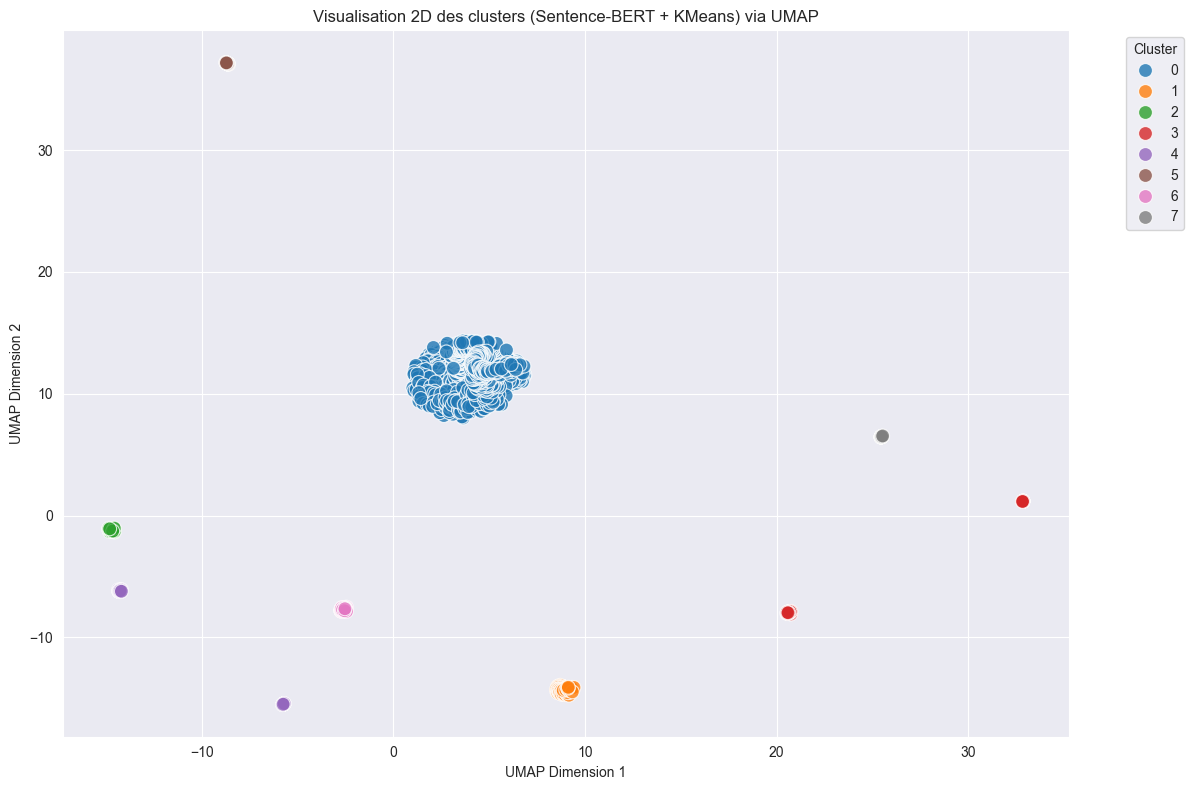

In [76]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Réduction de dimension avec UMAP (2D)
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(embeddings)

# 2. Ajouter les coordonnées UMAP dans le DataFrame
df_filtered['x'] = X_umap[:, 0]
df_filtered['y'] = X_umap[:, 1]

# 3. Visualisation 2D des clusters issus de Sentence-BERT + KMeans
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_filtered,
    x='x', y='y',
    hue='cluster_sbert',
    palette='tab10',
    s=100,
    alpha=0.8
)

plt.title("Visualisation 2D des clusters (Sentence-BERT + KMeans) via UMAP")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

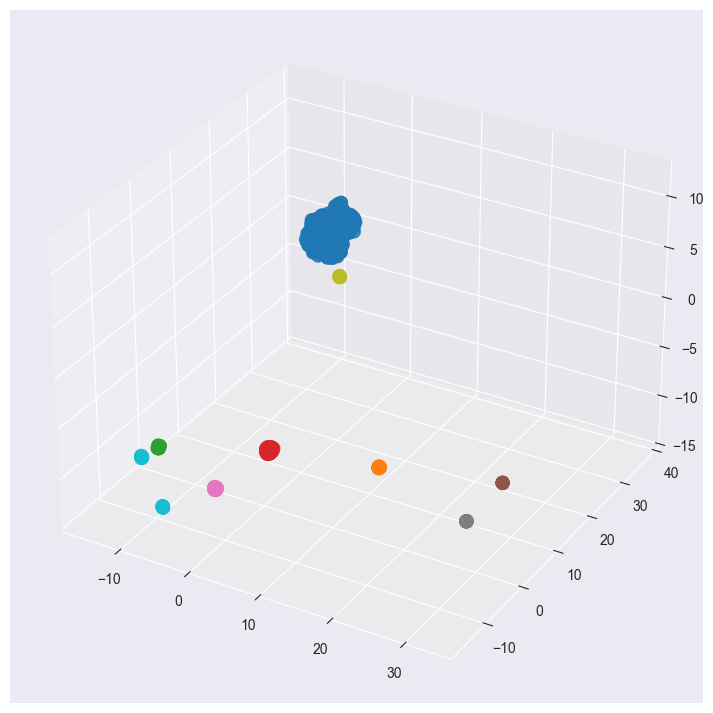

In [77]:
# 4. Visualisation 3D avec matplotlib
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

df_filtered['x'] = X_umap[:, 0]
df_filtered['y'] = X_umap[:, 1]

scatter = ax.scatter(
    df_filtered['x'], df_filtered['y'], df_filtered['z'],
    c=df_filtered['group_id'], cmap='tab10', s=80, alpha=0.8
)


In [78]:
#clustering

C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


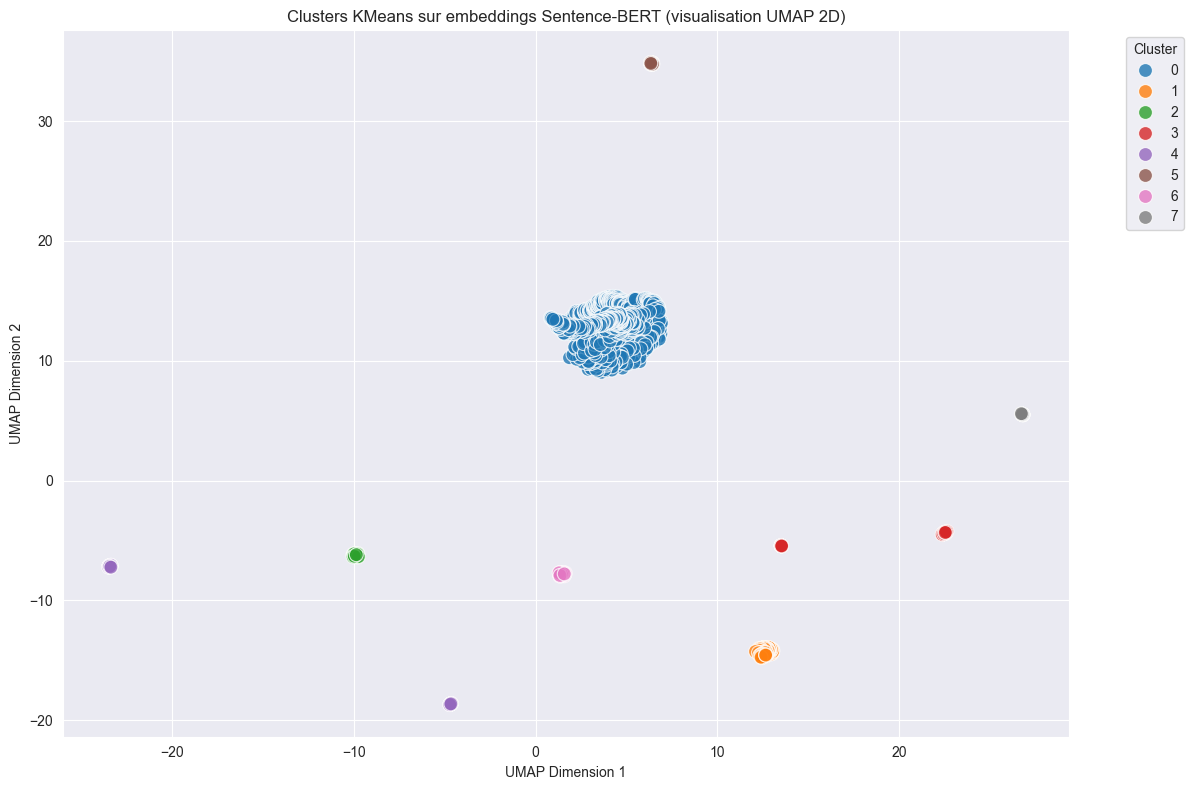

In [79]:
from sklearn.cluster import KMeans
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# Supposons que 'embeddings' contient les vecteurs issus de Sentence-BERT
# 1. Appliquer KMeans (choisir par exemple 8 clusters)
k = 8
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(embeddings)

# Ajouter les clusters dans le DataFrame
df_filtered['cluster_kmeans'] = clusters

# 2. Réduction dimensionnelle UMAP en 2D pour visualisation
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(embeddings)

df_filtered['x'] = X_umap[:, 0]
df_filtered['y'] = X_umap[:, 1]

# 3. Visualisation 2D avec seaborn
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_filtered,
    x='x',
    y='y',
    hue='cluster_kmeans',
    palette='tab10',
    s=100,
    alpha=0.8
)
plt.title("Clusters KMeans sur embeddings Sentence-BERT (visualisation UMAP 2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
#DBSCAN

C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


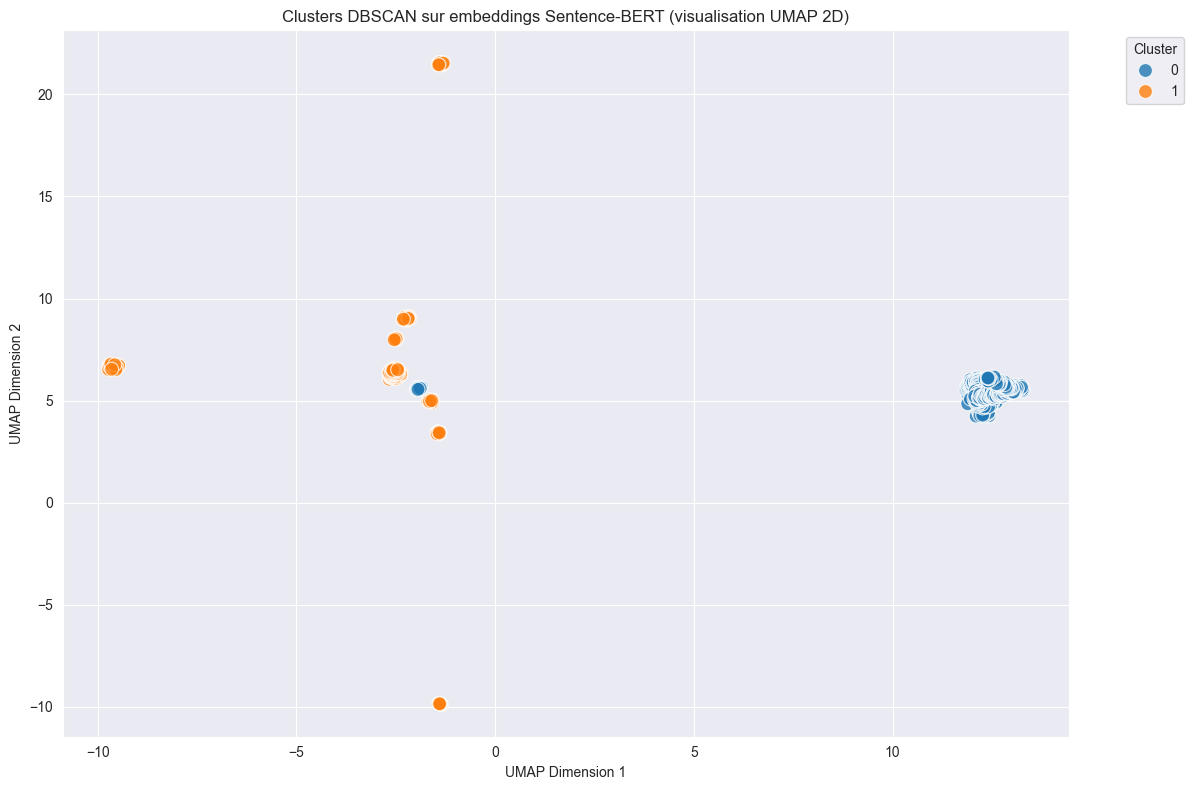

In [81]:
from sklearn.cluster import DBSCAN
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Appliquer DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5)
clusters = dbscan.fit_predict(embeddings)

# Ajouter les clusters au DataFrame
df_filtered['cluster_dbscan'] = clusters

# 2. UMAP pour visualisation
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(embeddings)
df_filtered['x'] = X_umap[:, 0]
df_filtered['y'] = X_umap[:, 1]

# 3. Visualisation
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_filtered,
    x='x',
    y='y',
    hue='cluster_dbscan',
    palette='tab10',
    s=100,
    alpha=0.8
)
plt.title("Clusters DBSCAN sur embeddings Sentence-BERT (visualisation UMAP 2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


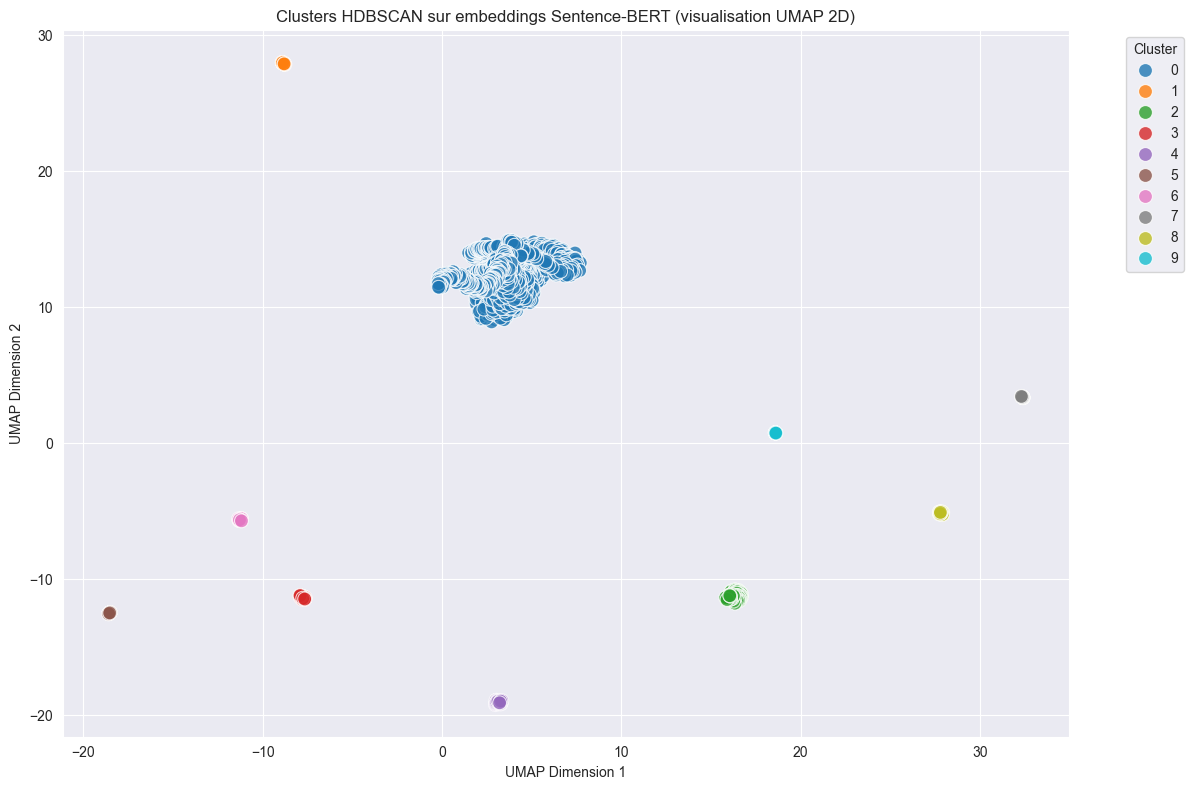

In [82]:
import hdbscan
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Appliquer HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=5)
clusters = hdb.fit_predict(embeddings)

df_filtered['cluster_hdbscan'] = clusters

# 2. UMAP pour visualisation
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(embeddings)
df_filtered['x'] = X_umap[:, 0]
df_filtered['y'] = X_umap[:, 1]

# 3. Visualisation
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_filtered,
    x='x',
    y='y',
    hue='cluster_hdbscan',
    palette='tab10',
    s=100,
    alpha=0.8
)
plt.title("Clusters HDBSCAN sur embeddings Sentence-BERT (visualisation UMAP 2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

In [83]:
from sentence_transformers import SentenceTransformer

# 1. Charger le modèle pré-entraîné Sentence-BERT
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Encoder les erreurs en vecteurs
embeddings = model.encode(df_filtered['error_type'].astype(str).tolist())

C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


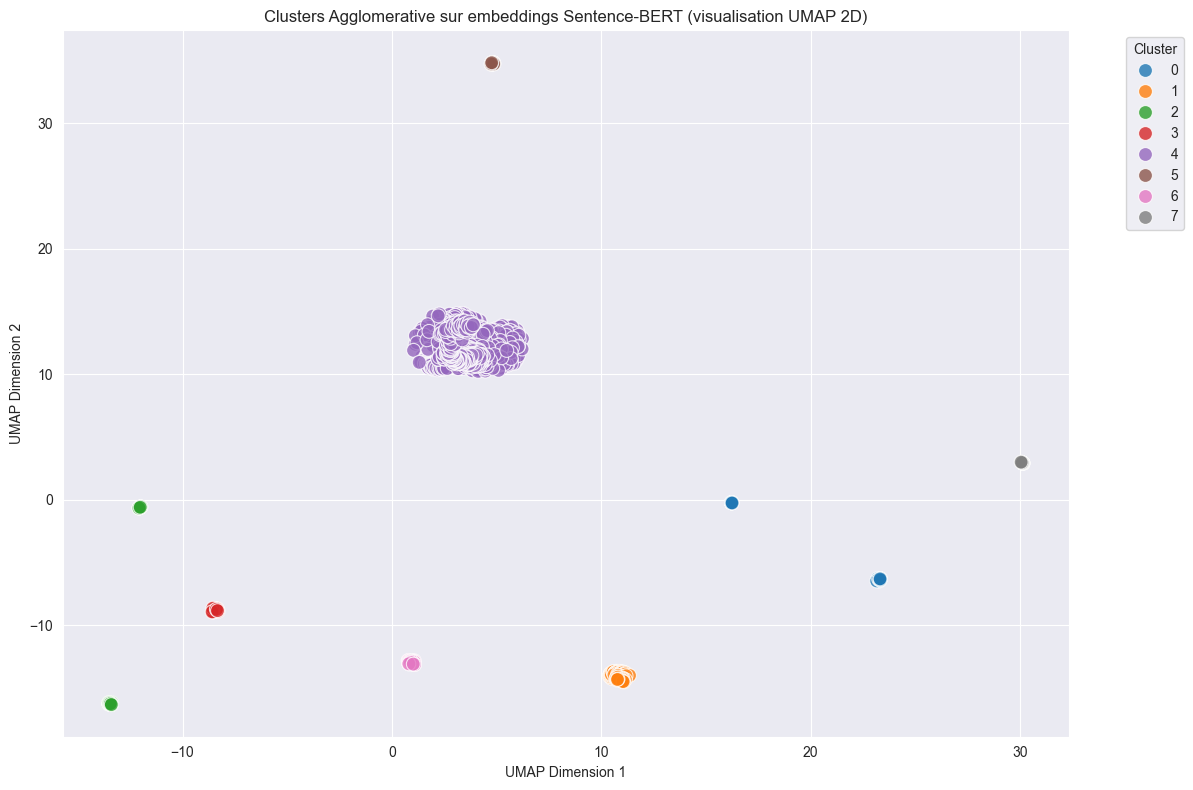

In [84]:
from sklearn.cluster import AgglomerativeClustering
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Appliquer Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=8)
clusters = agglo.fit_predict(embeddings)

df_filtered['cluster_agglo'] = clusters

# 2. UMAP pour visualisation
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(embeddings)
df_filtered['x'] = X_umap[:, 0] 
df_filtered['y'] = X_umap[:, 1]

# 3. Visualisation
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_filtered,
    x='x',
    y='y',
    hue='cluster_agglo',
    palette='tab10',
    s=100,
    alpha=0.8
)
plt.title("Clusters Agglomerative sur embeddings Sentence-BERT (visualisation UMAP 2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [85]:
df_filtered2 = df_filtered[["error_type", "cluster_sbert",	"cluster_kmeans"	,"cluster_dbscan",	"cluster_agglo"	,"cluster_hdbscan"]]

In [86]:
df_filtered2.drop_duplicates()

,error_type,cluster_sbert,cluster_kmeans,cluster_dbscan,cluster_agglo,cluster_hdbscan
0,pas d'erreur,0,0,0,4,0
2,selenium.common.exceptions.NoSuchElementException,3,3,1,0,8
5,TypeError,2,2,1,3,3
23,Utils.Common.StepFailedException,1,1,1,1,2
41,selenium.common.exceptions.StaleElementReferen...,3,3,1,0,9
50,AttributeError,6,6,1,6,4
89,selenium.common.exceptions.ElementClickInterce...,7,7,1,7,7
95,Autre,5,5,0,5,1
104,UnicodeEncodeError,4,4,1,2,6
146,UnicodeEncodeError,4,4,1,2,5


In [87]:
#on garde kmeans et agglo et on procede aux metriques d evaluation 

In [88]:
#metrique d eevaluation

In [89]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels = df_filtered['cluster_kmeans']

print("Évaluation du clustering KMeans :")
print(f"Silhouette Score        : {silhouette_score(embeddings, labels):.3f}")
print(f"Davies-Bouldin Index    : {davies_bouldin_score(embeddings, labels):.3f}")
print(f"Calinski-Harabasz Index : {calinski_harabasz_score(embeddings, labels):.3f}")


Évaluation du clustering KMeans :
Silhouette Score        : 0.991
Davies-Bouldin Index    : 0.224
Calinski-Harabasz Index : 53610.219


In [90]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels = df_filtered['cluster_dbscan']

print("Évaluation du clustering Agglomerative :")
print(f"Silhouette Score        : {silhouette_score(embeddings, labels):.3f}")
print(f"Davies-Bouldin Index    : {davies_bouldin_score(embeddings, labels):.3f}")
print(f"Calinski-Harabasz Index : {calinski_harabasz_score(embeddings, labels):.3f}")

Évaluation du clustering Agglomerative :
Silhouette Score        : 0.822
Davies-Bouldin Index    : 0.681
Calinski-Harabasz Index : 3655.645


In [91]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels = df_filtered['cluster_agglo']

print("Évaluation du clustering Agglomerative :")
print(f"Silhouette Score        : {silhouette_score(embeddings, labels):.3f}")
print(f"Davies-Bouldin Index    : {davies_bouldin_score(embeddings, labels):.3f}")
print(f"Calinski-Harabasz Index : {calinski_harabasz_score(embeddings, labels):.3f}")


Évaluation du clustering Agglomerative :
Silhouette Score        : 0.991
Davies-Bouldin Index    : 0.224
Calinski-Harabasz Index : 53610.219


In [92]:
#CNN

In [93]:
num_classes = df_filtered['error_type'].nunique()
# ou si tu as déjà un groupement :
# num_classes = df_filtered['group_id'].nunique()

In [94]:
import os
import pandas as pd

image_dir = "C:/Users/hbakl/OneDrive/Desktop/Projet PFA/screenshots_base64"

# liste des fichiers images
file_list = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Créer un dataframe avec juste les fichiers
df_files = pd.DataFrame({'filename': file_list})

# Si tu as un dataframe avec les labels, par ex df_labels
# tu peux faire un merge sur 'filename'

# df_filtered = pd.merge(df_files, df_labels, on='filename')

print(df_files.head())

                                            filename
0  TC-58151-Search Corporate-Addresses_1750641350...
1  TC-58151-Search Corporate-Addresses_1750641350...
2  TC-58158-Search Corporate-Contacts_17506415596...
3  TC-58158-Search Corporate-Contacts_17506415596...
4  TC-58162-Search Corporate-Details_175064169559...


In [95]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
import os

image_dir = "C:/Users/hbakl/OneDrive/Desktop/Projet PFA/screenshots_base64"
file_list = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

model_fe = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(128,128,3))

features = []
for fname in file_list:
    img_path = os.path.join(image_dir, fname)
    img = load_img(img_path, target_size=(128,128))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    feature_vector = model_fe.predict(img_array)
    features.append(feature_vector.flatten())

features = np.array(features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [96]:
from sklearn.cluster import KMeans

num_clusters = 5  # choisis selon ton cas

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(features)

In [97]:
clusters

array([1, 1, 1, 1, 0, 0, 2, 2, 1, 1, 4, 4, 3, 3], dtype=int32)

In [98]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.cluster import KMeans

# Chemin vers dossier images
image_dir = "C:/Users/hbakl/OneDrive/Desktop/Projet PFA/screenshots_base64"
# Liste des fichiers images
file_list = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Charger modèle MobileNetV2 pré-entraîné (sans la dernière couche)
model_fe = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(128,128,3))

# Extraire features de chaque image
features = []
for fname in file_list:
    img_path = os.path.join(image_dir, fname)
    img = load_img(img_path, target_size=(128,128))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    feature_vector = model_fe.predict(img_array)
    features.append(feature_vector.flatten())

features = np.array(features)
print(f"Features shape: {features.shape}")  # Vérifie la forme (N_images, N_features)

# Clustering KMeans sur les features extraites
num_clusters = 5  # adapte selon ton besoin
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(features)

# Créer un dataframe avec filename + cluster assigné
df_clustered = pd.DataFrame({'filename': file_list, 'cluster': clusters})
print(df_clustered.head())

# OPTION : enregistrer ce dataframe pour annoter tes images
df_clustered.to_csv('image_clusters.csv', index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Features shape: (14, 1280)
                                            filename  cluster
0  TC-58151-Search Corporate-Addresses_1750641350...        1
1  TC-58151-Search Corporate-Addresses_1750641350...        1
2  TC-58158-Search Corporate-Contacts_17506415596...        1
3  TC-58158-Search Corporate-Contacts_17506415596...        1
4  TC-58162-Search Corporate-Details_175064169559...        0


In [99]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Chemin vers dossier images
image_dir = "C:/Users/hbakl/OneDrive/Desktop/Projet PFA/screenshots_base64"

# df_clustered contient 'filename' et 'cluster'
# Charger les images en numpy array
images = []
for fname in df_clustered['filename']:
    path = os.path.join(image_dir, fname)
    img = load_img(path, target_size=(128, 128))
    img_array = img_to_array(img) / 255.0  # normalisation entre 0 et 1
    images.append(img_array)

X = np.array(images)

# Encoder les clusters en entiers (au cas où)
#le = LabelEncoder()
#y_int = le.fit_transform(df_clustered['cluster'])
#num_classes = len(le.classes_)

# One-hot encoding des labels
y = to_categorical(df_clustered['cluster'], num_classes=num_classes)

# Définir un modèle CNN simple (adapté à ton nombre de classes)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compiler le modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraîner le modèle avec validation split
history = model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20


C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 2.2248 - val_accuracy: 0.0000e+00 - val_loss: 16.2656
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5455 - loss: 6.3273 - val_accuracy: 0.0000e+00 - val_loss: 10.8685
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5455 - loss: 1.8515 - val_accuracy: 0.0000e+00 - val_loss: 9.7224
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.1818 - loss: 3.1930 - val_accuracy: 0.0000e+00 - val_loss: 8.6562
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.3636 - loss: 2.7425 - val_accuracy: 0.0000e+00 - val_loss: 7.0784
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.1818 - loss: 1.7601 - val_accuracy: 0.0000e+00 - val_loss: 5.9880
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7273 - loss: 1.1530 - val_accuracy: 0.0000e+00 - val_loss: 5.5843
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5455 - loss: 1.1241 - val_accuracy

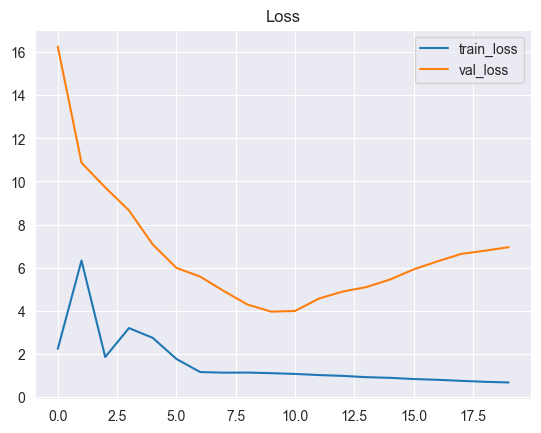

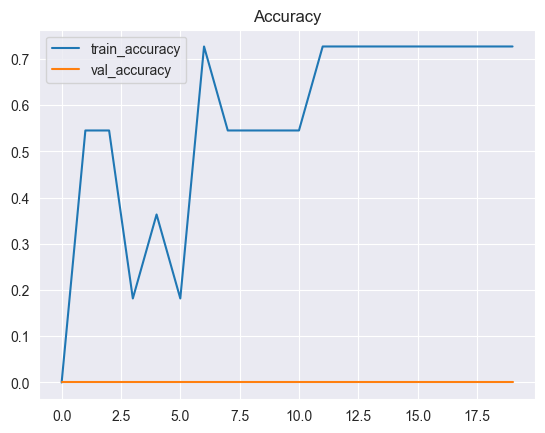

In [100]:
import matplotlib.pyplot as plt

# Courbe de perte
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.show()

# Courbe de précision
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

In [101]:
#on cherche maintenant a ameliorer notre modele 

In [102]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split

# === 1. Chargement des images ===
image_dir = "C:/Users/hbakl/OneDrive/Desktop/Projet PFA/screenshots_base64"
images = []

# Charger images + normalisation
for fname in df_clustered['filename']:
    path = os.path.join(image_dir, fname)
    img = load_img(path, target_size=(128, 128))
    img_array = img_to_array(img) / 255.0
    images.append(img_array)

X = np.array(images)

# === 2. Préparation des labels ===
num_classes = df_clustered['cluster'].nunique()
y = to_categorical(df_clustered['cluster'], num_classes=num_classes)

# === 3. Split train / val ===
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.34, stratify=df_clustered['cluster'], random_state=42
)


# === 4. Légère Data Augmentation ===
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# === 5. Modèle CNN simple ===
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# === 6. Compilation ===
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# === 7. Entraînement ===
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=30
)

# === 8. Évaluation finale ===
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"\n✅ Performance finale - Val_accuracy: {val_acc:.2%}, Val_loss: {val_loss:.4f}")


Epoch 1/30


C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2222 - loss: 1.6365 - val_accuracy: 0.4000 - val_loss: 8.8062
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.4444 - loss: 8.2325 - val_accuracy: 0.2000 - val_loss: 3.4587
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.1111 - loss: 3.4678 - val_accuracy: 0.0000e+00 - val_loss: 3.5104
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.2222 - loss: 2.5662 - val_accuracy: 0.0000e+00 - val_loss: 2.6914
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.2222 - loss: 1.9786 - val_accuracy: 0.4000 - val_loss: 1.8919
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.4444 - loss: 1.5927 - val_accuracy: 0.4000 - val_loss: 1.6354
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.4444 - loss: 1.5333 - val_accuracy: 0.4000 - val_loss: 1.5128
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.4444 - loss: 1.4781 - val_accuracy: 0.4000 - val_loss: 1.501

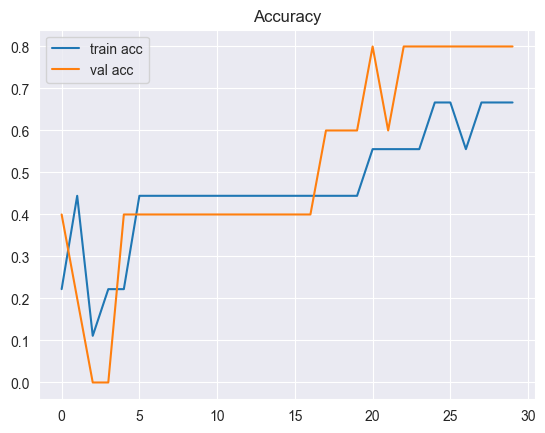

In [103]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()
plt.show()

Le graphique montre l'évolution de l'**accuracy** (précision) pendant l'entraînement d’un modèle sur 30 époques pour :

* **train acc** (accuracy sur l'ensemble d'entraînement, en rouge)
* **val acc** (accuracy sur l'ensemble de validation, en bleu)

### Analyse :

1. **Tendance générale** :

   * Les deux courbes montrent une amélioration globale au fil des époques.
   * Cela suggère que le modèle apprend bien avec le temps.

2. **Comportement de la courbe de validation** :

   * La courbe de validation fluctue plus que celle d'entraînement, ce qui est courant.
   * Vers la fin, la validation atteint des valeurs élevées (\~0.9), ce qui est très bon signe.

3. **Écart entre les courbes** :

   * À certaines époques, la validation est meilleure que l'entraînement. Cela peut indiquer une régularisation efficace (ex. : dropout).
   * Pas de signe clair de **surapprentissage (overfitting)**, car la validation ne se dégrade pas.

### Conclusion :

Le modèle semble bien généraliser, avec une précision en validation supérieure ou égale à celle d'entraînement. Tu peux encore l’améliorer en :

* Ajoutant un lissage de la courbe pour mieux visualiser les tendances (ex: moyenne mobile),
* Évaluant d'autres métriques (perte, f1-score, etc.),
* Testant le modèle sur des données non vues (test set) pour confirmer sa performance.

In [104]:
pred = model.predict(X_val)
print("Exemple : prédiction =", np.argmax(pred[0]), " / réel =", np.argmax(y_val[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Exemple : prédiction = 1  / réel = 4


In [105]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

print(classification_report(y_true_classes, y_pred_classes))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.67      1.00      0.80         2
           3       1.00      1.00      1.00         1
           4       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.67      0.75      0.70         5
weighted avg       0.67      0.80      0.72         5



C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hbakl\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

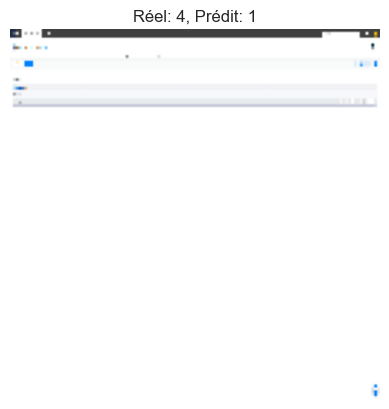

In [106]:
#Afficher les images mal classées 

import matplotlib.pyplot as plt

for i in range(len(X_val)):
    true = y_true_classes[i]
    pred = y_pred_classes[i]
    if true != pred:
        plt.imshow(X_val[i])
        plt.title(f"Réel: {true}, Prédit: {pred}")
        plt.axis('off')
        plt.show()
